## DATA CLEANING AND EXPLORATORY DATA ANALYSIS

### IMPORT LIBRARIES

In [332]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### LOAD THE DATASET

This dataset contains all purchases made for an online retail company based in the UK.

In [333]:
raw_data = pd.read_csv("OnlineRetail.csv")
df = raw_data.copy()

### DATASET FAMILIARIZATION

In [334]:
#View data structure
df.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [335]:
#Check the rows and columns
df.shape

(541909, 8)

In [336]:
#View data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [337]:
#summarize missing values in every column
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

### DATA CLEANING
#### 1. Missing Data

In [338]:
#Drop missing values in the Description column
df = df.dropna(subset=['Description'])
#dropped 0.3% (1454) of rows

In [339]:
#Replace missing values in the "CustomerID" column with 'Unknown'
df['CustomerID'] = df['CustomerID'].fillna('Unknown')
#Replaced 25%(133626) of rows with 'Unknown

#### 2. Duplicates

In [340]:
#Find duplicated rows
df.duplicated().sum()

#Remove duplicated rows
df.drop_duplicates(inplace=True)
#found and removed 1% of (5268) rows

#### 3. Standardization
##### Consistency in data entry

In [341]:
#Display unique values in all columns
for col in df.columns:
    print(f"\ncolumns: {col}")
    print(df[col].unique())


columns: InvoiceNo
['536365' '536366' '536367' ... '581585' '581586' '581587']

columns: StockCode
['85123A' '71053' '84406B' ... '90214U' '47591b' '23843']

columns: Description
['WHITE HANGING HEART T-LIGHT HOLDER' 'WHITE METAL LANTERN'
 'CREAM CUPID HEARTS COAT HANGER' ... 'lost'
 'CREAM HANGING HEART T-LIGHT HOLDER' 'PAPER CRAFT , LITTLE BIRDIE']

columns: Quantity
[     6      8      2     32      3      4     24     12     48     18
     20     36     80     64     10    120     96     23      5      1
     -1     50     40    100    192    432    144    288    -12    -24
     16      9    128     25     30     28      7     72    200    600
    480     -6     14     -2     11     33     13     -4     -5     -7
     -3     70    252     60    216    384     27     15     22     19
     17     21     34     47    108     52  -9360     75    270     42
    240     90    320   1824    204     69    -36   -192   -144    160
   2880   1400     39    -48    -50     56     26   1440   

##### Case Formatting

In [342]:
# Change the text in  the Description column from upper case to proper case
df['Description'] = df['Description'].str.title()

##### Data Type Formatting

In [343]:
#Format the CustomerID data type from float to text
df['CustomerID'] = df['CustomerID'].astype(str)

### 4. Data Validation

In [344]:
df.describe()

,Quantity,UnitPrice
count,535187.000000,535187.000000
mean,9.671593,4.645242
std,219.059056,97.364810
min,-80995.000000,-11062.060000
25%,1.000000,1.250000
50%,3.000000,2.080000
75%,10.000000,4.130000
max,80995.000000,38970.000000


##### Find and remove rows with  extreme outliers

In [345]:
#Detect extreme outliers using the interquartile range method
#Quantity
Q1 = df['Quantity'].quantile(0.25)
Q3 = df['Quantity'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = 1 - 1.5 * IQR
upper_bound = 1 + 1.5 * IQR

#Remove all extreme outliers
df = df[(df['Quantity'] >= lower_bound) & (df['Quantity'] <= upper_bound)]

In [346]:
#Using the interquartile range method with different variables to remove outliers in the unit price column
#UnitPrice
QRT1 = df['UnitPrice'].quantile(0.25)
QRT3 = df['UnitPrice'].quantile(0.75)

IQR2 = QRT3 - QRT1

lower = 1 - 1.5 * IQR2
upper = 1 + 1.5 * IQR2

#Remove all extreme outliers
df = df[(df['UnitPrice'] >= lower) & (df['UnitPrice'] <= upper)]

##### Find and remove rows with zero values in numerical columns

In [347]:
df = df[(df['Quantity'] != 0) & (df['UnitPrice'] != 0)]
#1060 rows of data were removed due to values of zero in the unit price column

### FEATURE ENGINEERING
#### 1. Create a 'Sales' column

In [348]:
# Using business logic, create a sales column with the formula; df['Sales'] = df['Quantity'] * df['UnitPrice']
df['Sales'] = df['Quantity'] * df['UnitPrice']

#### 2. Seperate the 'InvoiceDate' column into Day, Month, and Year

In [349]:
#Split the 'InvoiceDate' column to seperate the date from the time
df['Date'] = df['InvoiceDate'].str.split(' ').str[0]

#Create day, month, and year columns; format to Integer
df['Day'] = df['Date'].str.split('/').str[1].astype(int)
df['MonthNumber'] = df['Date'].str.split('/').str[0].astype(int)
df['MonthName'] = pd.to_datetime(df['MonthNumber'], format='%m').dt.strftime('%b')
df['Year'] = df['Date'].str.split('/').str[2].astype(int)



#### 3. Drop unwanted columns

In [350]:
#Drop the Date, InvoiceDate, and MonthNumber columns
df.drop(['Date', 'InvoiceDate', 'MonthNumber'], axis = 1, inplace=True)

### FINAL DATA INSPECTION

In [351]:
df.head(5)

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country,Sales,Day,MonthName,Year
0,536365,85123A,White Hanging Heart T-Light Holder,6,2.55,17850.0,United Kingdom,15.30,1,Dec,2010
1,536365,71053,White Metal Lantern,6,3.39,17850.0,United Kingdom,20.34,1,Dec,2010
2,536365,84406B,Cream Cupid Hearts Coat Hanger,8,2.75,17850.0,United Kingdom,22.00,1,Dec,2010
3,536365,84029G,Knitted Union Flag Hot Water Bottle,6,3.39,17850.0,United Kingdom,20.34,1,Dec,2010
4,536365,84029E,Red Woolly Hottie White Heart.,6,3.39,17850.0,United Kingdom,20.34,1,Dec,2010


In [352]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 379481 entries, 0 to 541908
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    379481 non-null  object 
 1   StockCode    379481 non-null  object 
 2   Description  379481 non-null  object 
 3   Quantity     379481 non-null  int64  
 4   UnitPrice    379481 non-null  float64
 5   CustomerID   379481 non-null  object 
 6   Country      379481 non-null  object 
 7   Sales        379481 non-null  float64
 8   Day          379481 non-null  int64  
 9   MonthName    379481 non-null  object 
 10  Year         379481 non-null  int64  
dtypes: float64(2), int64(3), object(6)
memory usage: 34.7+ MB


In [353]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
UnitPrice      0
CustomerID     0
Country        0
Sales          0
Day            0
MonthName      0
Year           0
dtype: int64

#### Assesment of initial length of data, final length, and removed rows

In [354]:
initial_rows = len(raw_data)
current_rows = len(df)
rows_removed = initial_rows - current_rows
print(f"Original length: {initial_rows}")
print(f"Final length: {current_rows}")
print(f"Rows removed: {rows_removed}")

Original length: 541909
Final length: 379481
Rows removed: 162428


### SAVE CLEANED FILE

In [355]:
df.to_csv("Cleaned_OnlineRetail.csv", index = False)

### DATA CLEANING SUMMARY
##### Data Cleaning Process
1. Performed data familiarization to assess the dataset structure, data types, and missing values.
2. Handled missing data by removing or replacing null values where necessary.
3. Identified and removed duplicate records.
4. Standardized the data through consistent text casing and proper data type formatting.
5. Conducted data validation by detecting and removing extreme outliers and zero values in numeric columns.
6. Performed feature engineering by:
* Creating a new Sales column
* Splitting the Date column into Day, Month, and Year and formating into integer
* Dropping unnecessary columns
7. Conducted a final inspection of the cleaned dataset.
8. Saved the cleaned dataset as a CSV file.

### EXPLORATORY DATA ANALYSIS

#### 1. Load and inspect cleaned dataset

In [356]:
df.describe()

,Quantity,UnitPrice,Sales,Day,Year
count,379481.000000,379481.000000,379481.00000,379481.000000,379481.000000
mean,4.702254,2.222525,9.05788,15.002501,2010.923907
std,4.156968,1.289934,8.80799,8.667172,0.265148
min,-12.000000,0.001000,-64.68000,1.000000,2010.000000
25%,1.000000,1.250000,2.55000,7.000000,2011.000000
50%,3.000000,1.950000,5.85000,15.000000,2011.000000
75%,8.000000,2.950000,15.00000,22.000000,2011.000000
max,14.000000,5.400000,75.46000,31.000000,2011.000000


In [357]:
cleaned_data = pd.read_csv("Cleaned_OnlineRetail.csv")
df2 = cleaned_data.copy()
df2.head(3)

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country,Sales,Day,MonthName,Year
0,536365,85123A,White Hanging Heart T-Light Holder,6,2.55,17850.0,United Kingdom,15.30,1,Dec,2010
1,536365,71053,White Metal Lantern,6,3.39,17850.0,United Kingdom,20.34,1,Dec,2010
2,536365,84406B,Cream Cupid Hearts Coat Hanger,8,2.75,17850.0,United Kingdom,22.00,1,Dec,2010


In [ ]:
#Generate summary statistics
df2.describe()

,Quantity,UnitPrice,Sales,Day,Year
count,379481.000000,379481.000000,379481.00000,379481.000000,379481.000000
mean,4.702254,2.222525,9.05788,15.002501,2010.923907
std,4.156968,1.289934,8.80799,8.667172,0.265148
min,-12.000000,0.001000,-64.68000,1.000000,2010.000000
25%,1.000000,1.250000,2.55000,7.000000,2011.000000
50%,3.000000,1.950000,5.85000,15.000000,2011.000000
75%,8.000000,2.950000,15.00000,22.000000,2011.000000
max,14.000000,5.400000,75.46000,31.000000,2011.000000


In [359]:
df2.shape

(379481, 11)

In [360]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 379481 entries, 0 to 379480
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    379481 non-null  object 
 1   StockCode    379481 non-null  object 
 2   Description  379481 non-null  object 
 3   Quantity     379481 non-null  int64  
 4   UnitPrice    379481 non-null  float64
 5   CustomerID   379481 non-null  object 
 6   Country      379481 non-null  object 
 7   Sales        379481 non-null  float64
 8   Day          379481 non-null  int64  
 9   MonthName    379481 non-null  object 
 10  Year         379481 non-null  int64  
dtypes: float64(2), int64(3), object(6)
memory usage: 31.8+ MB


### 2. Data Visualization

#### Visualize Time series plots, Regional and Product Performance, and Relationship between variables.

Text(0.5, 1.0, 'Correlation between Quantity, Unit Price and Sales')

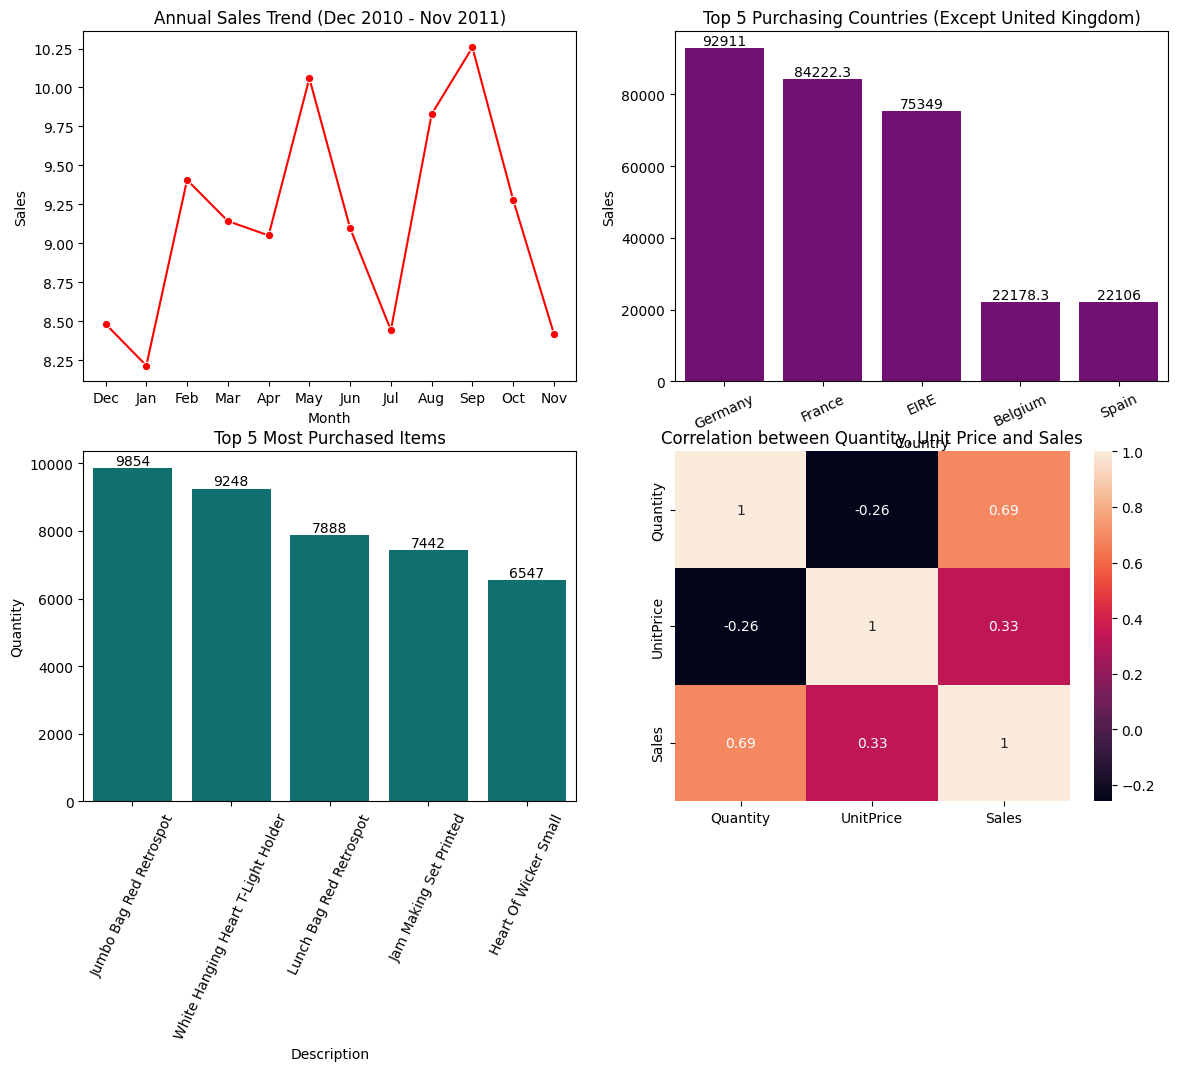

In [361]:
plt.figure(figsize=(14,10))

#Annual Sales Trend
plt.subplot(2,2,1)
sns.lineplot(y='Sales', x = 'MonthName', data = df2, color='red', marker='o', markersize=6, errorbar=None)
plt.title("Annual Sales Trend (Dec 2010 - Nov 2011)")
plt.xlabel("Month")

#REGIONAL ANALYSIS

#Top 5 Performing Countries (Excluding United Kingdom)
df2_no_uk = df2[df2['Country'] != 'United Kingdom']
top_countries = df2_no_uk.groupby('Country')['Sales'].sum().sort_values(ascending=False).head(5)
plt.subplot(2,2,2)
tc = sns.barplot(top_countries, color='purple')
plt.title("Top 5 Purchasing Countries (Except United Kingdom)")
plt.xticks(rotation=25)
#Add labels
for container in tc.containers:
    tc.bar_label(container)

#PRODUCT PERFORMANCE

#Top 5 purchases
top_5_purchases = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(5)
plt.subplot(2,2,3)
tp = sns.barplot(top_5_purchases, color='teal')
plt.title("Top 5 Most Purchased Items")
plt.xticks(rotation=65)
#Add labels
for container in tp.containers:
    tp.bar_label(container)

#RELATIONSHIP BETWEEN VARIABLES

#Correlation between numeric features
correlation = df2[['Quantity', 'UnitPrice', 'Sales']].corr()
plt.subplot(2,2,4)
sns.heatmap(correlation, annot=True)
plt.title("Correlation between Quantity, Unit Price and Sales")

#### Least Performing Countries by Sales and Products by Quantity

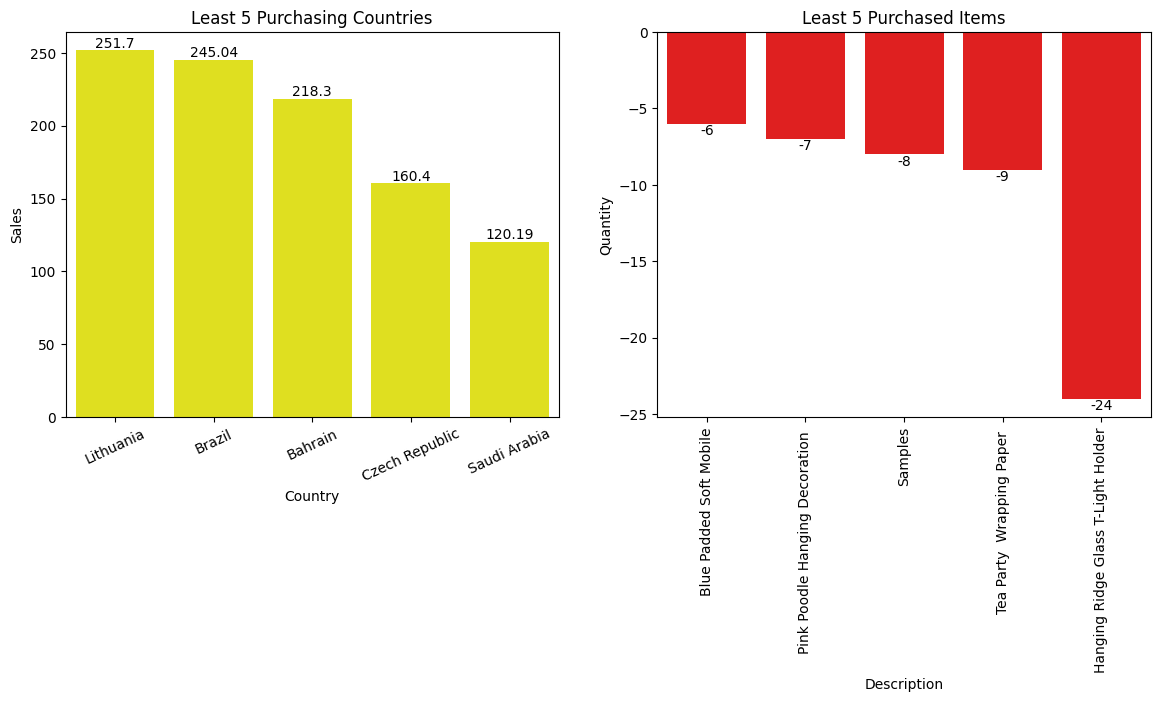

In [362]:
plt.figure(figsize=(14,5))

#REGIONAL ANALYSIS

#Top 5 Performing Countries (Excluding United Kingdom)
df2_no_uk = df2[df2['Country'] != 'United Kingdom']
least_countries = df2_no_uk.groupby('Country')['Sales'].sum().sort_values(ascending=False).tail(5)
plt.subplot(1,2,1)
lc = sns.barplot(least_countries, color='yellow')
plt.title("Least 5 Purchasing Countries")
plt.xticks(rotation=25)
#Add labels
for container in lc.containers:
    lc.bar_label(container)

#PRODUCT PERFORMANCE

#Top 5 purchases
least_5_purchases = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).tail(5)
plt.subplot(1,2,2)
lp = sns.barplot(least_5_purchases, color='red')
plt.title("Least 5 Purchased Items")
plt.xticks(rotation=90)
for container in lp.containers:
    lp.bar_label(container)



### Business Insights
* Sales declined in January, April, and July, while peak sales were recorded in February, May, and September.
* The top three purchasing countries (UK excluded) by sales were Germany (92,911), France (84,222), and EIRE (75,349). The least-performing countries included Bahrain (218), Czech Republic (160), and Saudi Arabia (120).
* The product “Jumbo Bag Red Retrospot” (9,854)recorded the highest quantity ordered, while “Hanging Ridge Glass T-Light Holder” (-24) recorded the lowest quantity sold due to product returns, resulting in negative values.
* A weak negative correlation (-0.26) exists between unit price and quantity ordered, indicating that lower prices tend to encourage higher purchase volumes.
* Sales and quantity ordered showed a strong positive correlation (0.69), suggesting that higher order quantities significantly contribute to increased sales revenue.

### Recommendations
* Increase inventory levels and staffing during peak sales periods. For example, promote gift items in February for Valentine’s Day, children-related products in May, and seasonal decorations toward September in preparation for Halloween.
* Implement targeted marketing campaigns in low-performing regions such as Bahrain, the Czech Republic, and Saudi Arabia to improve customer engagement and sales.
* Maintain higher inventory levels for high-demand products such as “Jumbo Bag Red Retrospot.” Additionally investigate the causes of low demand and product returns associated with “Hanging Heart T-Light Holder.”
* Introduce promotional pricing and discount strategies where appropriate, as lower unit prices appear to encourage increased purchasing volume.

### EDA Keynotes
The Online Retail dataset underwent extensive cleaning, during which approximately 30% of the rows were removed due to missing values, duplicates, outliers, and invalid zero-value entries.

The United Kingdom was excluded from the country-level sales comparison because its exceptionally high sales value (3,021,709.224) would create significant bias and reduce the comparability of other countries.

The findings suggest that the company can improve overall performance through:

* Increased inventory during peak sales periods
* Stronger regional marketing strategies
* Greater availability of high-demand products
* Improvements to low-performing products
* Strategic promotional discount campaigns

### Exploratory Data Analysis (EDA) Process
1. Loaded the cleaned dataset for analysis.
2. Generated summary statistics to understand the distribution and characteristics of the data.
3. Created visualizations to analyze trends across time, regions, products, and relationships between variables.
4. Generated insights and recommendations based on the analysis findings.
5. Concluded the analysis with a summary of key findings and the overall analytical process.

